In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

In [2]:
from collections import Counter

from palmprint.datasets.bmpd import (
    BMPDDatasetBuilder,
    BMPDDatasetConfig,
    QualityFilterConfig,
    SplitConfig,
)

from palmprint.sampling.pairs import generate_balanced_pairs

In [12]:
root_dir = Path("../data/processed/bmpd_roi")

config = BMPDDatasetConfig(
    roi_dir=Path(root_dir),
    split=SplitConfig(
        seed=42,
        train_ratio=0.7,
        val_ratio=0.1,
        test_ratio=0.2,
    ),
    quality_filter=QualityFilterConfig(
        apply_quality_filter=True,
        project_root=Path("../"),
        quality_csv_path=Path("../data/qc/roi_quality.csv"),
        verbose=True,
    ),
)

builder = BMPDDatasetBuilder(config)

In [13]:
splits = builder.build_splits()


=== ROI QUALITY FILTERING ===
Total images:     1612
Removed (bad):    89
Kept:             1523
Percent removed:  5.52%


In [14]:
for split_name, samples in splits.items():
    subject_ids = sorted({s.identity_id for s in samples})
    hands = Counter(s.hand for s in samples)

    print(f"\n{split_name.upper()}")
    print(f"Images: {len(samples)}")
    print(f"Identities (person+hand): {len(subject_ids)}")
    print(f"Hand distribution: {dict(hands)}")
    print(f"Sample identities: {subject_ids[:10]}")


TRAIN
Images: 1071
Identities (person+hand): 56
Hand distribution: {'R': 564, 'L': 507}
Sample identities: ['001_L', '001_R', '002_L', '003_R', '004_L', '004_R', '005_L', '005_R', '006_L', '009_L']

VAL
Images: 148
Identities (person+hand): 8
Hand distribution: {'R': 108, 'L': 40}
Sample identities: ['007_R', '014_R', '018_R', '022_R', '024_L', '024_R', '036_L', '040_R']

TEST
Images: 304
Identities (person+hand): 16
Hand distribution: {'L': 205, 'R': 99}
Sample identities: ['002_R', '003_L', '007_L', '008_L', '008_R', '010_L', '015_L', '015_R', '016_L', '017_L']


In [15]:
train_pairs = generate_balanced_pairs(
    splits["train"],
    num_pairs=1000,
    seed=42,
)

pair_counts = Counter(label for _, _, label in train_pairs)

print("Pair distribution:")
print(pair_counts)

Pair distribution:
Counter({0: 500, 1: 500})


In [16]:
import cv2
import matplotlib.pyplot as plt

def show_pair(pair):
    img1_path, img2_path, label = pair

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title("Image 1")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(f"Image 2 | Label={label}")
    plt.axis("off")

    plt.show()

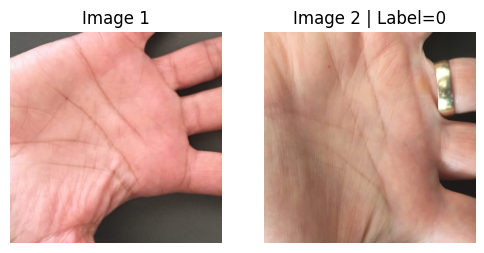

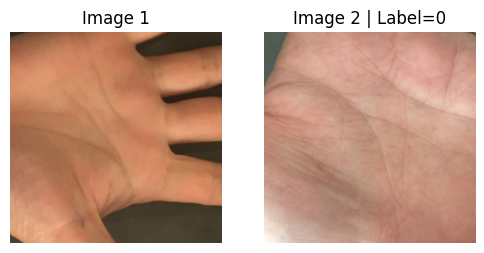

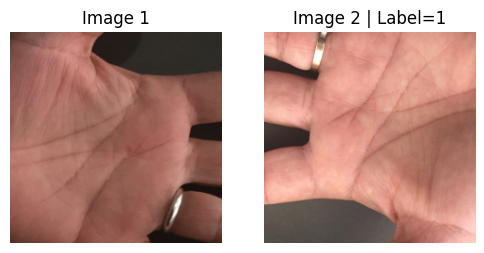

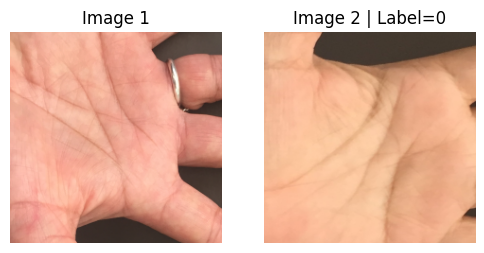

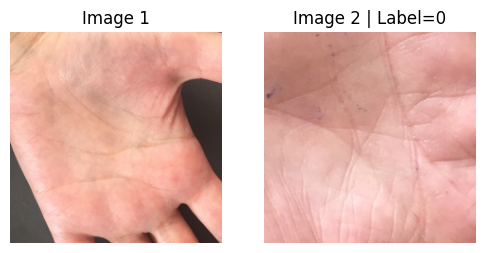

In [17]:
# Show a few examples
for i in range(5):
    show_pair(train_pairs[i])